## 패션 MNIST

In [19]:
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

In [ ]:
# train 과 valid data 분리
from sklearn.model_selection import train_test_split

train_scaled = (train_input / 255.0).reshape(-1, 28 * 28)

train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )

#### Layer 를 추가하는 방법 - 1

In [7]:
# Layer 만들기
dense1 = keras.layers.Dense(100, activation='sigmoid', input_shape=(784,)) # 은닉층
dense2 = keras.layers.Dense(10, activation='softmax') # 출력층
# 입력층은 층으로 생각 안 해서 생략 가능, 다만 아래와 같이 warning 창 뜸

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# 전체 모델에 층 추가
model = keras.Sequential([dense1, dense2])

In [10]:
# summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

---
#### Layer를 추가하는 방법 - 2

In [11]:
model = keras.Sequential(
    [
        keras.layers.Dense(100, activation='sigmoid', input_shape=(784,), name='hidden'),
        keras.layers.Dense(10, activation='softmax', name='output')
    ],
    name = '패션 MNIST 모델'
)

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "패션 MNIST 모델"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

----
#### Layer를 추가하는 방법 - 3

In [ ]:
model = keras.Sequential()
model.add(keras.layers.Dense(100, activation='sigmoid', input_shape=(784,), name = 'hidden'))
model.add(keras.layers.Dense(10, activation='softmax', name = 'output'))
# 3개중 가장 편리할 수 있음

In [17]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

> (3) 번째 방법이 가장 많이 사용됨. 파이썬 코드를 중간에 삽입 가능하기 때문.

In [18]:
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_scaled,
    train_target,
    epochs=5
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8050 - loss: 0.5740
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8520 - loss: 0.4118
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8650 - loss: 0.3760
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8716 - loss: 0.3534
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8788 - loss: 0.3361


---
#### 입력층을 이미지 그대로 사용하기

In [22]:
(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )

In [24]:
train_scaled.shape

(48000, 28, 28)

In [25]:
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=(28, 28)))
model.add(keras.layers.Dense(100, activation='relu'))

model.add(keras.layers.Dense(10, activation='softmax'))

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

---
## 다시 한 번

In [ ]:
(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )

In [ ]:
# 손실함수
model = keras.Sequential()
model.add(keras.layers.Dense(100, activation='sigmoid', input_shape=(784,), name = 'hidden'))
model.add(keras.layers.Dense(10, activation='softmax', name = 'output'))

In [ ]:
# 학습하기
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_scaled,
    train_target,
    epochs=20
)

In [29]:
# 검증데이터로 확인
import numpy as np
from tensorflow import keras
from sklearn.model_selection import train_test_split

# 1. 데이터 로드 및 전처리
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

# [중요] Fashion MNIST는 (28, 28) 형태이므로, 
# 만약 Dense 층의 input_shape=(784,)를 쓰려면 데이터를 1차원으로 펼쳐주어야(Flatten) 합니다.
train_input_flatten = train_input.reshape(-1, 28*28)
train_scaled = train_input_flatten / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

# 2. 모델 생성
model = keras.Sequential()
model.add(keras.layers.Dense(100, activation='sigmoid', input_shape=(784,), name='hidden'))
model.add(keras.layers.Dense(10, activation='softmax', name='output'))

# 3. 손실함수 및 컴파일
model.compile(
    optimizer='adam', # 성능을 위해 adam 옵티마이저를 권장합니다.
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. 가장 정확도가 높은 순간을 포착할 콜백(Callback) 설정
# validation_data(검증 데이터) 기준 정확도가 가장 높을 때의 모델 가중치를 자동으로 파일로 저장합니다.
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath='best-model.keras', 
    monitor='val_accuracy',       # 검증 정확도(val_accuracy)를 기준으로 모니터링
    save_best_only=True           # 가장 점수가 높은 순간의 모델만 저장
)

# 5. 모델 훈련 (훈련 기록을 history 변수에 담습니다)
history = model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data=(val_scaled, val_target), # 최적의 에포크를 판단할 기준 데이터 제공
    callbacks=[checkpoint_cb]                 # 콜백 등록
)

# 6. 20번의 에포크 중 가장 정확도가 높았던 최적의 에포크 찾아내기
val_accuracy_list = history.history['val_accuracy']
best_epoch = np.argmax(val_accuracy_list) + 1 # 인덱스가 0부터 시작하므로 1을 더합니다.
best_accuracy = np.max(val_accuracy_list)

print("\n" + "="*40)
print(f"🥇 가장 정확도가 높은 최적의 에포크: {best_epoch} epoch")
print(f"🎯 그때의 최고 검증 정확도: {best_accuracy:.4f}")
print("="*40)

# 7. (선택) 가장 좋은 성능을 냈던 상태의 모델을 불러와 사용하기
# best_model = keras.models.load_model('best-model.keras')

Epoch 1/20


c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8051 - loss: 0.5811 - val_accuracy: 0.8407 - val_loss: 0.4408
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8543 - loss: 0.4088 - val_accuracy: 0.8562 - val_loss: 0.3901
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8669 - loss: 0.3707 - val_accuracy: 0.8660 - val_loss: 0.3640
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8748 - loss: 0.3467 - val_accuracy: 0.8712 - val_loss: 0.3538
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8821 - loss: 0.3275 - val_accuracy: 0.8743 - val_loss: 0.3425
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8857 - loss: 0.3125 - val_accuracy: 0.8752 - val_loss: 0.3391
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8901 - loss: 0.2986 - val_accuracy: 0.8779 - val_loss: 0.3366
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8955 - loss: 0.2859 - val_accurac

In [32]:
import numpy as np
from tensorflow import keras
from sklearn.model_selection import train_test_split

# 1. 데이터 로드 및 전처리
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

# 2D 이미지를 1D 데이터로 Flatten 및 정규화
train_input_flatten = train_input.reshape(-1, 28*28)
test_input_flatten = test_input.reshape(-1, 28*28)

train_scaled = train_input_flatten / 255.0
test_scaled = test_input_flatten / 255.0

# Train / Validation 분리
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

# 2. 모델 생성
model = keras.Sequential()
model.add(keras.layers.Dense(100, activation='relu', input_shape=(784,), name='hidden'))
model.add(keras.layers.Dense(10, activation='softmax', name='output'))

# 3. 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. 최적 모델 저장을 위한 콜백 설정
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath='best-model.keras', 
    monitor='val_accuracy',       # 검증 정확도 기준
    save_best_only=True           # 최고 성능 모델만 저장
)

# 5. 모델 훈련
history = model.fit(
    train_scaled,
    train_target,
    epochs=40,
    validation_data=(val_scaled, val_target),
    callbacks=[checkpoint_cb],
    verbose=1
)

# 6. 최적의 에포크 인덱스 찾기
val_accuracy_list = history.history['val_accuracy'] # -> model.fit() 함수 실행 결과가 자동으로 history 딕셔너리 변수에 저장됨. 해당 변수에 loss, accuracy, val_loss, val_accuracy 등이 저장됨.
best_epoch_index = np.argmax(val_accuracy_list) # 리스트 인덱스 (0부터 시작)
best_epoch = best_epoch_index + 1               # 실제 에포크 차수 (1부터 시작)

# 7. 최적 에포크 시점의 Train 및 Valid 정확도 추출
best_train_accuracy = history.history['accuracy'][best_epoch_index]
best_val_accuracy = val_accuracy_list[best_epoch_index]

# 8. 가장 성능이 좋았던 저장된 모델을 불러와 Test 정확도 측정
best_model = keras.models.load_model('best-model.keras')
test_loss, best_test_accuracy = best_model.evaluate(test_scaled, test_target, verbose=0)

# 9. 최종 결과 출력
print("\n" + "="*50)
print(f"🥇 최적의 에포크: {best_epoch} epoch")
print("-"*50)
print(f"📈 [Train]       훈련 정확도: {best_train_accuracy * 100:.2f}%")
print(f"🧪 [Validation]  검증 정확도: {best_val_accuracy * 100:.2f}%")
print(f"🎯 [Test]        🎯 최종 테스트 정확도: {best_test_accuracy * 100:.2f}%")
print("="*50)


Epoch 1/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8173 - loss: 0.5234 - val_accuracy: 0.8377 - val_loss: 0.4562
Epoch 2/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8590 - loss: 0.3941 - val_accuracy: 0.8587 - val_loss: 0.3987
Epoch 3/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8713 - loss: 0.3550 - val_accuracy: 0.8723 - val_loss: 0.3490
Epoch 4/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8798 - loss: 0.3272 - val_accuracy: 0.8742 - val_loss: 0.3520
Epoch 5/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8848 - loss: 0.3106 - val_accuracy: 0.8754 - val_loss: 0.3422
Epoch 6/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8932 - loss: 0.2902 - val_accuracy: 0.8847 - val_loss: 0.3242
Epoch 7/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8976 - loss: 0.2789 - val_accuracy: 0.8752 - val_loss: 0.3461
Epoch 8/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9004 - loss: 0.2694 - 

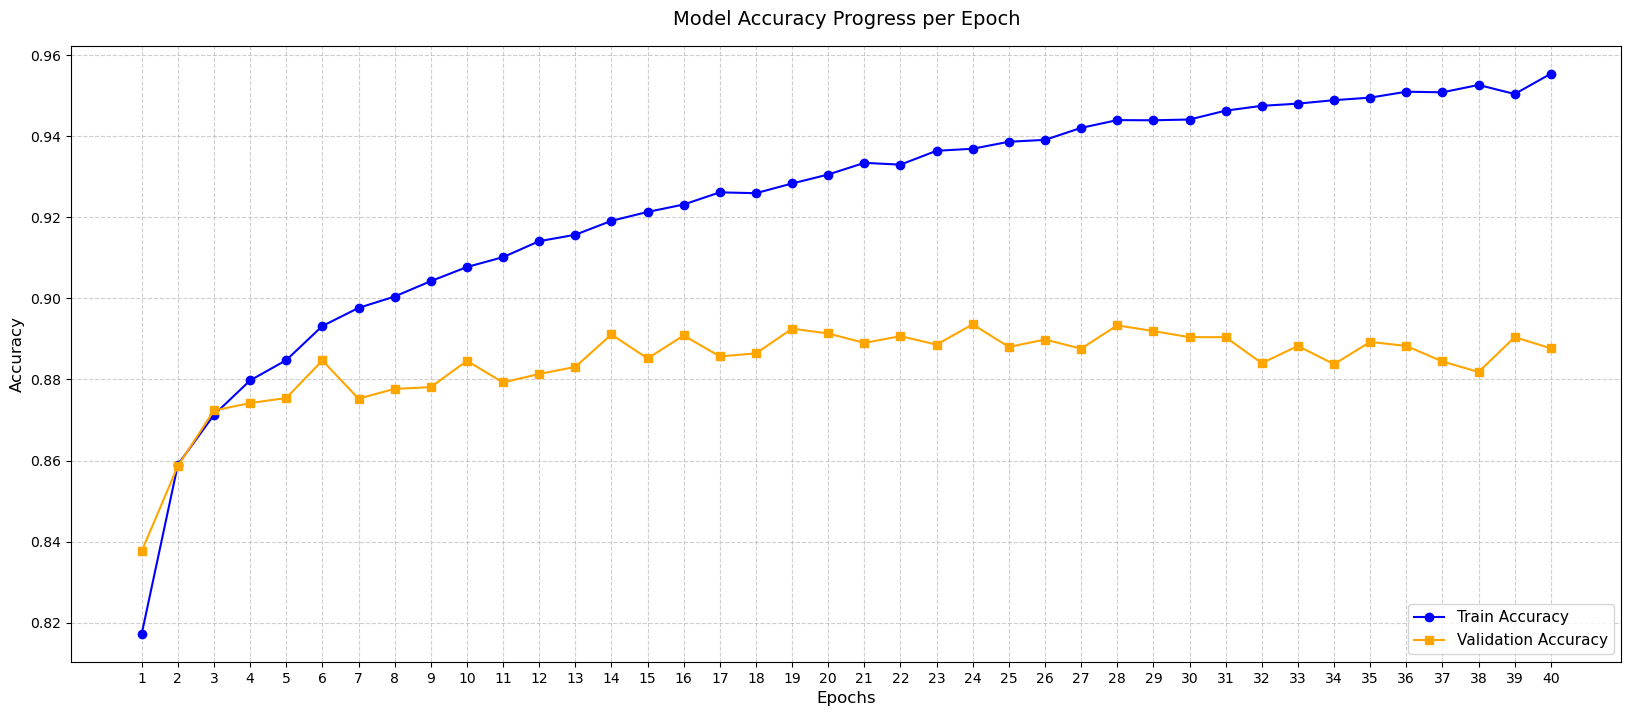

In [36]:
import matplotlib.pyplot as plt

# 1. history 객체에서 에포크별 train, valid 정확도 리스트 추출
train_acc_list = history.history['accuracy']
valid_acc_list = history.history['val_accuracy']

# 2. 에포크 수를 기준으로 x축 설정 (1부터 시작)
epochs_range = range(1, len(train_acc_list) + 1)

# 3. 그래프 그리기
plt.figure(figsize=(20, 8)) # 그래프 크기 설정
plt.plot(epochs_range, train_acc_list, label='Train Accuracy', marker='o', color='blue')
plt.plot(epochs_range, valid_acc_list, label='Validation Accuracy', marker='s', color='orange')

# 4. 그래프 꾸미기 (제목, 축 레이블, 범례 등)
plt.title('Model Accuracy Progress per Epoch', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(epochs_range) # x축 눈금을 에포크 정수로 고정
plt.grid(True, linestyle='--', alpha=0.6) # 배경 격자 추가
plt.legend(loc='lower right', fontsize=11) # 범례 위치 설정

# 5. 화면에 그래프 출력
plt.show()


> history 딕셔너리 변수 생성되는걸 이용하여 train, validation, test 정확도 수치를 각 epoch 마다 뽑아 낼 수 있다 -> 굳이 for 문 안 돌려도 됨